# Assignment 2
# Multilayer Perceptron (MLP) Classification

**Datasets:** Iris and Wine

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
sns.set_style("whitegrid")


In [4]:
data=load_iris()
df=pd.DataFrame(data.data , columns=data.feature_names)
df["target"]=data.target
display(df.head())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:

def run_experiment(loader,name):
    data=loader()
    df=pd.DataFrame(data.data,columns=data.feature_names)
    df["Target"]=data.target
    print("="*60);print(name);print("="*60)
    display(df.head())
    print("Shape:",df.shape)
    display(df.describe())
    print(df.info())
    print(df.isnull().sum())

    plt.figure(figsize=(5,3));sns.countplot(x="Target",data=df);plt.title(name+" Class Distribution");plt.show()
    df.hist(figsize=(12,8));plt.suptitle(name+" Histograms");plt.tight_layout();plt.show()
    plt.figure(figsize=(12,4));sns.boxplot(data=df.drop(columns="Target"));plt.xticks(rotation=45);plt.title(name+" Boxplots");plt.show()
    # sns.pairplot(df,hue="Target");plt.show()
    plt.figure(figsize=(8,6));sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm");plt.title(name+" Correlation");plt.show()

    X,y=data.data,data.target
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    sc=StandardScaler()
    X_train=sc.fit_transform(X_train);X_test=sc.transform(X_test)

    model=Sequential([
      Input(shape=(X.shape[1],)),
      Dense(16,activation="relu"),
      Dense(8,activation="relu"),
      Dense(len(np.unique(y)),activation="softmax")
    ])
    model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
    history=model.fit(X_train,y_train,epochs=50,batch_size=8,validation_split=0.2,verbose=1)
    model.summary()

    plt.figure(figsize=(7,4))
    plt.plot(history.history["accuracy"],label="Train")
    plt.plot(history.history["val_accuracy"],label="Validation")
    plt.title(name+" Accuracy")
    plt.xlabel("Epoch");plt.ylabel("Accuracy");plt.legend();plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"],label="Train")
    plt.plot(history.history["val_loss"],label="Validation")
    plt.title(name+" Loss")
    plt.xlabel("Epoch");plt.ylabel("Loss");plt.legend();plt.show()

    loss,acc=model.evaluate(X_test,y_test,verbose=0)
    y_pred=np.argmax(model.predict(X_test),axis=1)
    cm=confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(5,4));sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(name+" Confusion Matrix");plt.xlabel("Predicted");plt.ylabel("Actual");plt.show()
    print(classification_report(y_test,y_pred))
    return {"Dataset":name,"Accuracy":acc,"Loss":loss}


## Part A - Iris Dataset

Iris


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64


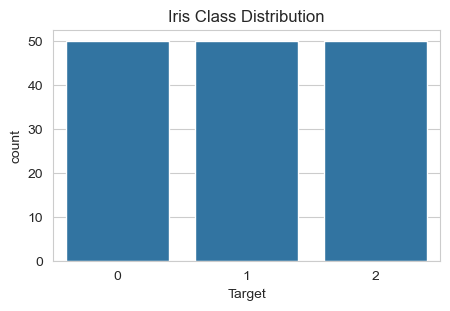

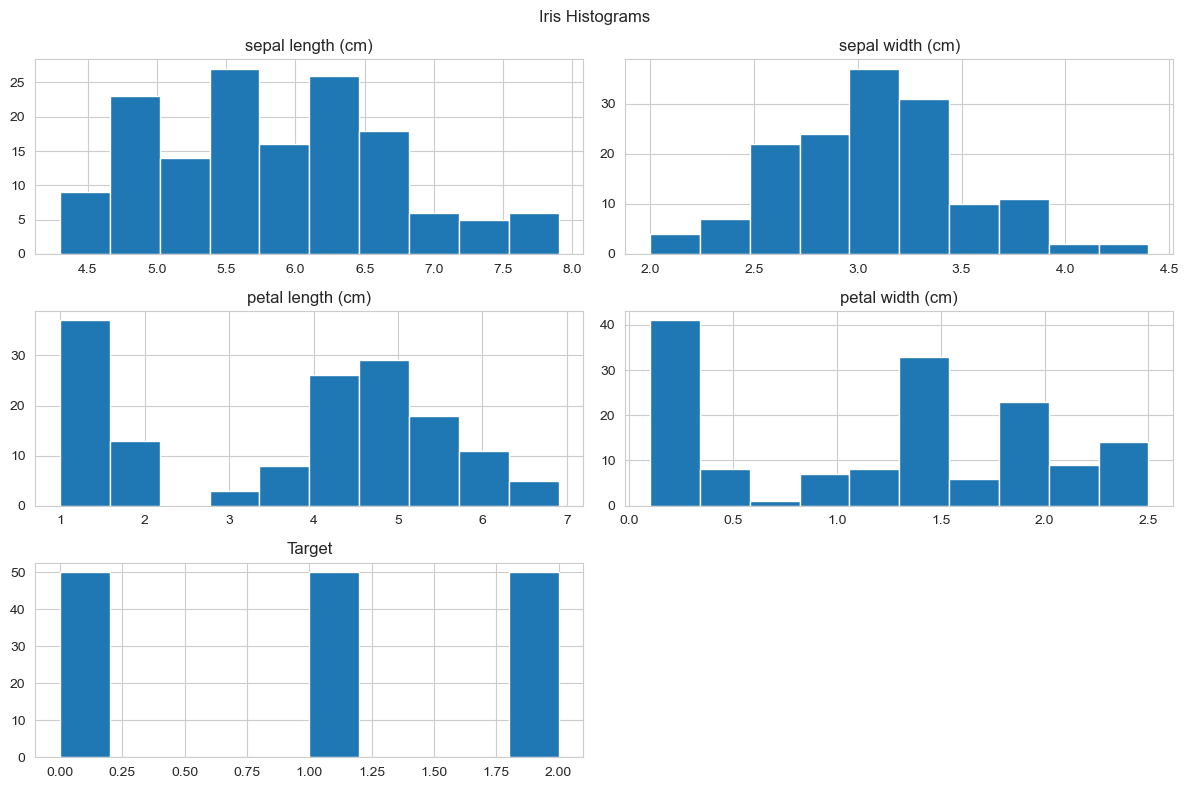

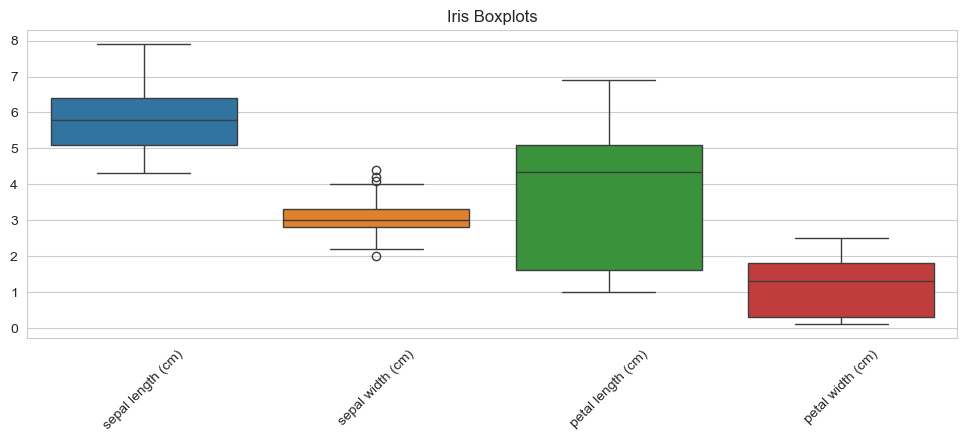

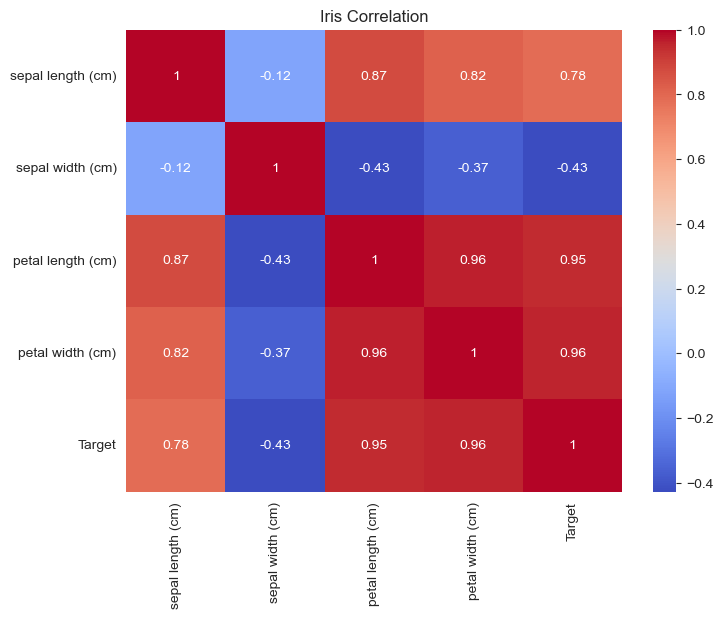

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2708 - loss: 1.1393 - val_accuracy: 0.3333 - val_loss: 1.0721
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3438 - loss: 1.0541 - val_accuracy: 0.4583 - val_loss: 0.9982
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5104 - loss: 0.9846 - val_accuracy: 0.6667 - val_loss: 0.9382
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6250 - loss: 0.9278 - val_accuracy: 0.6250 - val_loss: 0.8843
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.8745 - val_accuracy: 0.6250 - val_loss: 0.8378
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7083 - loss: 0.8292 - val_accuracy: 0.6667 - val_loss: 0.7981
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7292 - loss: 0.7859 - val_accuracy: 0.6667 - val_loss: 0.7625
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7083 - loss: 0.7482 - val_accuracy: 0.6667 - val_loss

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731 (2.86 KB)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 488 (1.91 KB)

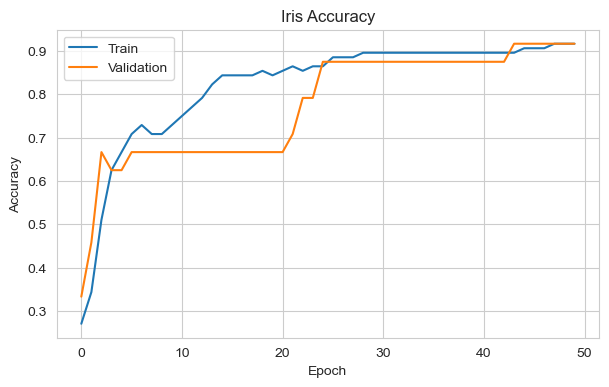

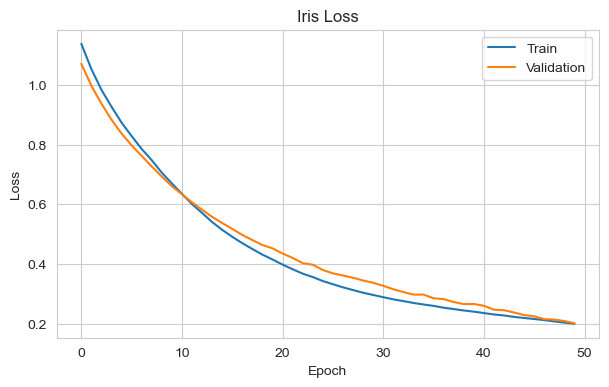

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


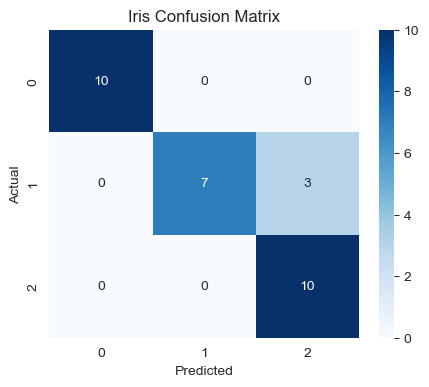

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.70      0.82        10
           2       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



In [6]:
iris_result=run_experiment(load_iris,'Iris')

## Part B - Wine Dataset

Wine


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Targe

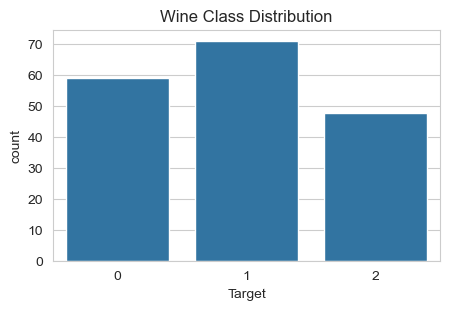

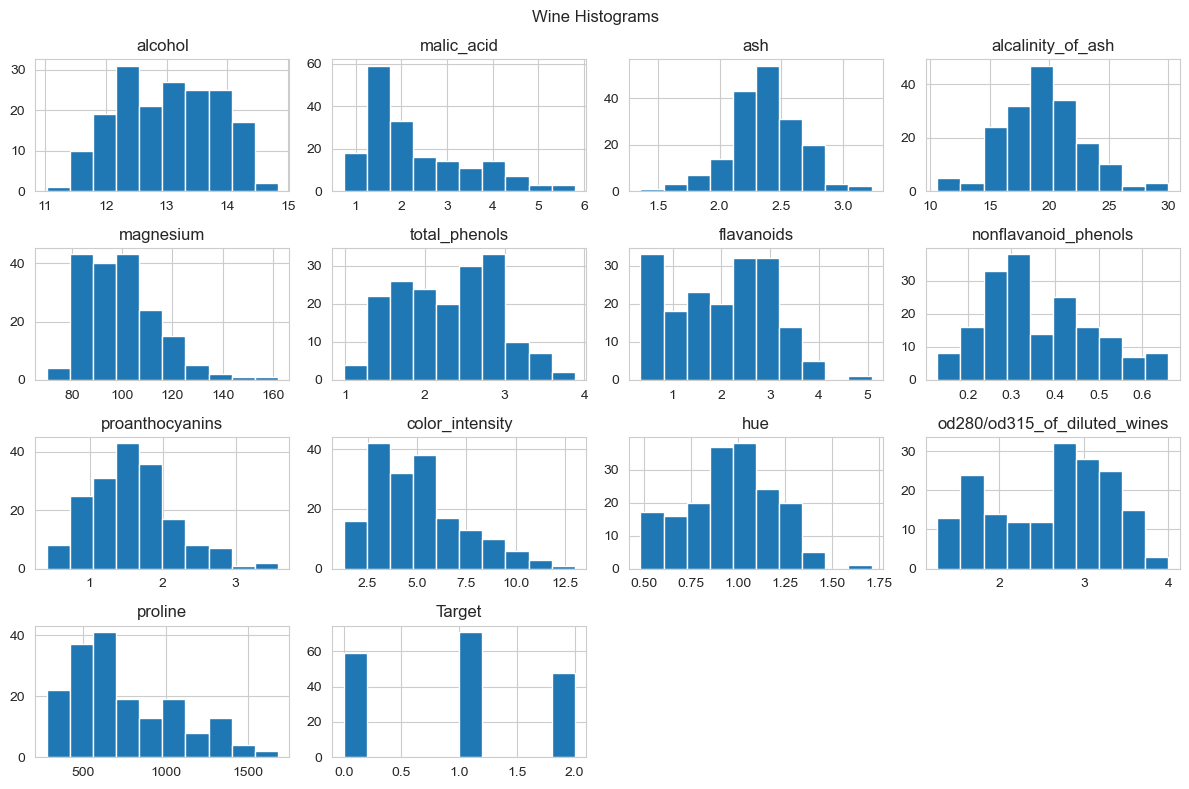

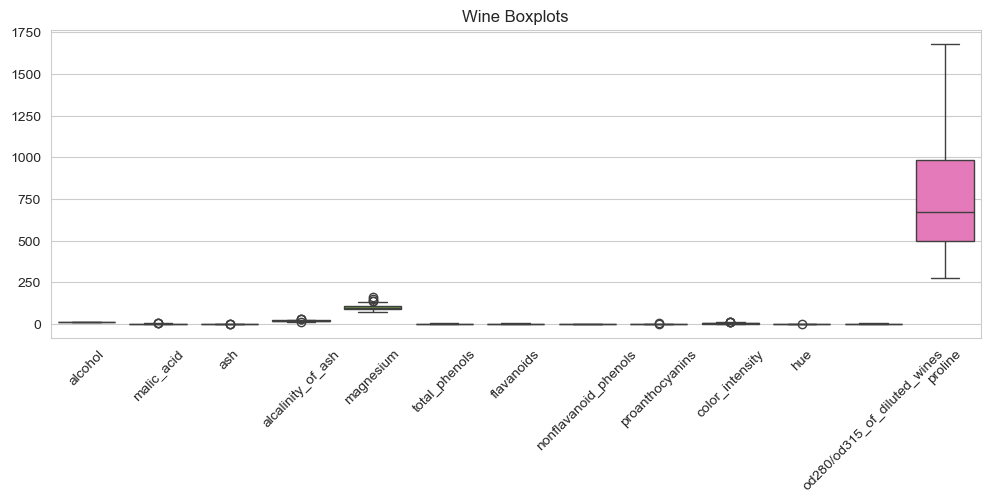

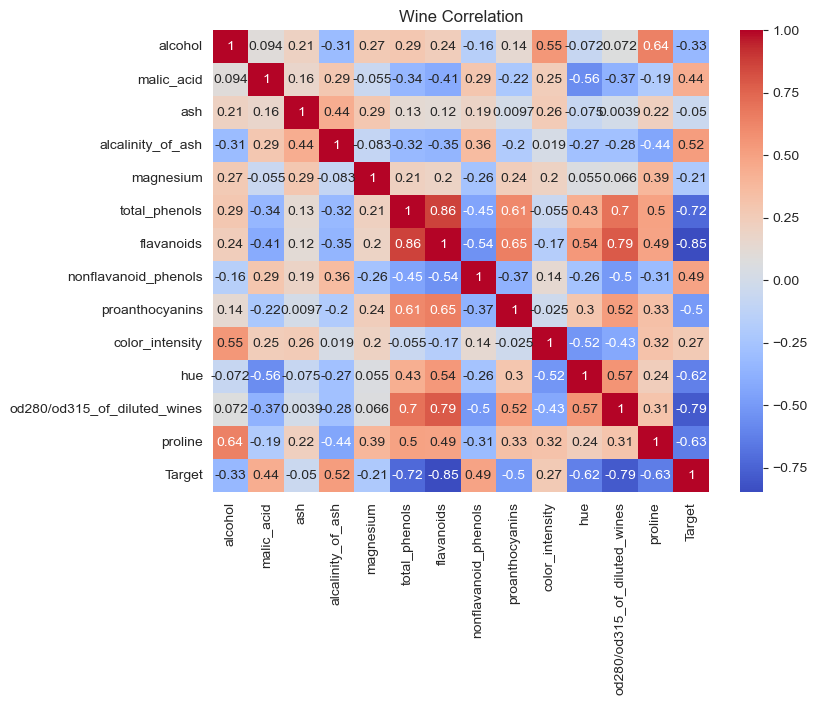

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3186 - loss: 1.1580 - val_accuracy: 0.6207 - val_loss: 0.8225
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4071 - loss: 1.0394 - val_accuracy: 0.6552 - val_loss: 0.7490
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5044 - loss: 0.9668 - val_accuracy: 0.7241 - val_loss: 0.6866
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5929 - loss: 0.9061 - val_accuracy: 0.7931 - val_loss: 0.6373
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6637 - loss: 0.8572 - val_accuracy: 0.7931 - val_loss: 0.5952
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7611 - loss: 0.8129 - val_accuracy: 0.8276 - val_loss: 0.5551
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8319 - loss: 0.7698 - val_accuracy: 0.8966 - val_loss: 0.5101
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8584 - loss: 0.7290 - val_accuracy: 0.9655 - val_loss

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,163 (4.55 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 776 (3.04 KB)

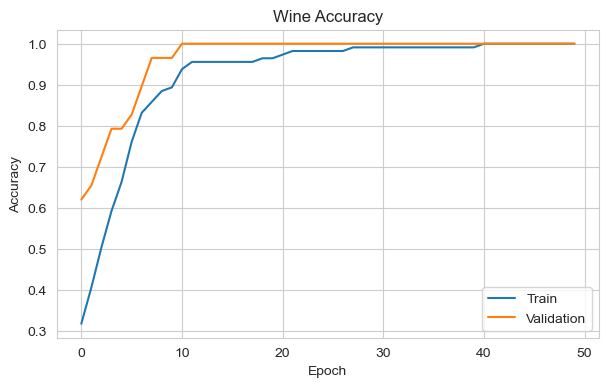

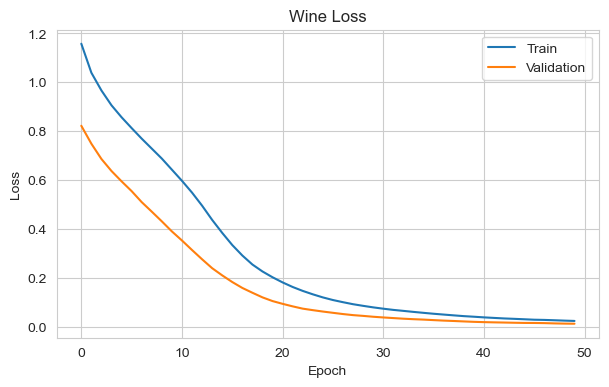

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


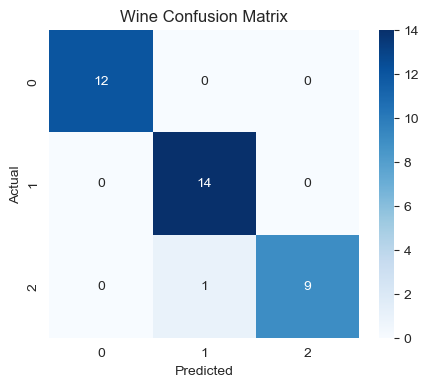

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [7]:
wine_result=run_experiment(load_wine,'Wine')

## Part C - Comparison

In [8]:
comparison=pd.DataFrame([iris_result,wine_result])
display(comparison)

best=comparison.loc[comparison['Accuracy'].idxmax(),'Dataset']
print("\nConclusion")
print(f"- {best} achieved the higher test accuracy in this run.")
print("- Both datasets were successfully classified using an MLP.")
print("- Training/validation curves, confusion matrices and classification reports were used to evaluate performance.")


,Dataset,Accuracy,Loss
0,Iris,0.900000,0.268986
1,Wine,0.972222,0.074301



Conclusion
- Wine achieved the higher test accuracy in this run.
- Both datasets were successfully classified using an MLP.
- Training/validation curves, confusion matrices and classification reports were used to evaluate performance.
